# ハミルトニアンシミュレーションの回路資源比較

Trotter–Suzuki、QSVT、multiproduct formula (MPF) を、同じ Pauli 和と誤差予算の下で比較します。小規模系では実際の statevector、大規模系では密行列を作らないゲート分解モデルを使います。

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from hamiltonian_resources import (
    BenchmarkConfig, benchmark_scaling, build_hamiltonian_qsvt_circuit,
    build_multiproduct_circuit, build_trotter_circuit, compare_with_exact,
    estimate_qsvt_degree, transverse_field_ising,
)
pd.set_option("display.max_columns", None)

## 1. ハミルトニアン入力

例として $H=-J\sum_i Z_iZ_{i+1}-h\sum_iX_i$ を使います。Qiskit の Pauli label は右端が qubit 0 です。任意の Pauli 和は `PauliHamiltonian.from_terms` で渡せます。

In [2]:
H = transverse_field_ising(3, coupling=1.0, field=0.7)
print(H.name, H.terms)
print(f"terms={H.term_count}, alpha=sum|h_j|={H.alpha:.3f}")

TFIM-3 (('IZZ', -1.0), ('ZZI', -1.0), ('IIX', -0.7), ('IXI', -0.7), ('XII', -0.7))
terms=5, alpha=sum|h_j|=4.100


## 2. 実回路を構成する

下の関数はいずれも Hamiltonian の密行列を指数化しません。QSVTは時刻と許容誤差からcosine/sine位相を合成し、MPFは既定の`new` scheduleでsegmentごとのrobust OAAを構成します。

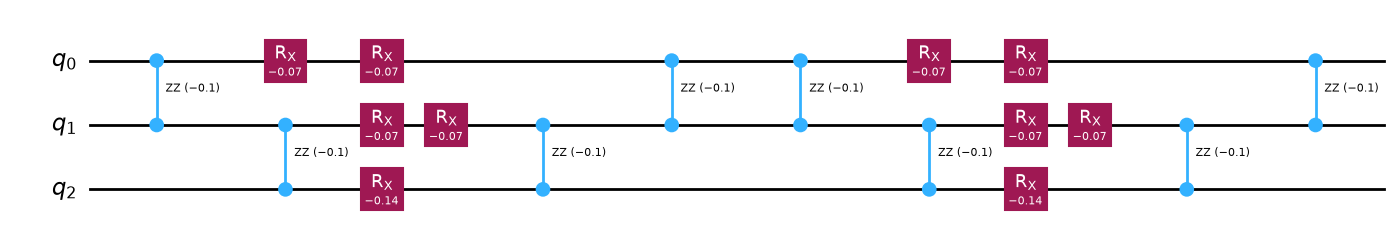

MPF metadata: {'algorithm': 'multiproduct', 'construction': 'robust-oaa-segments', 'm': 2, 'schedule': 'new', 'exponents': (1, 2), 'exponent_sum': 3, 'segments': 1, 'step_time': 0.2, 'coefficients': [-0.3333333333333333, 1.3333333333333333], 'coefficient_l1_norm': 1.6666666666666665, 'padding_weight': 0.3333333333333335, 'lcu_normalization': 2.0, 'formal_order': 4, 'amplitude_amplification': True, 'good_subspace': 'branch register all-zero', 'postselection': 'measure branch register as all-zero', 'trotter_step_queries_per_segment': 9, 'trotter_step_queries': 9, 'base_lcu_uses_per_segment': 3, 'logical_gate_counts_per_segment': {'prepare': 6, 'select': 3, 'good_reflection': 2, 'controlled_u2': 9}, 'logical_gate_counts': {'prepare': 6, 'select': 3, 'good_reflection': 2, 'controlled_u2': 9}, 'registers': {'branch': 2, 'system': 3}}
QSVT metadata: {'algorithm': 'qsvt-hamiltonian-simulation', 'construction': 'explicit-cos-sin-lcu', 'cosine_degree': 4, 'sine_degree': 5, 'alpha': 4.1, 'alpha_

In [3]:
time = 0.2
trotter_circuit = build_trotter_circuit(H, time, reps=2, order=2)
mpf_circuit = build_multiproduct_circuit(H, time, m=2, segments=1)
qsvt_circuit = build_hamiltonian_qsvt_circuit(H, time, epsilon=1e-2)

display(trotter_circuit.draw(output="mpl", fold=30))
print("MPF metadata:", mpf_circuit.metadata)
print("QSVT metadata:", qsvt_circuit.metadata)

## 3. 小規模系で厳密解と比較

MPF は branch=0 への postselection 後の fidelity と成功確率を別々に表示します。

In [4]:
validation = []
for reps in (1, 2, 4, 8):
    row = compare_with_exact(H, time, method="trotter", reps=reps, trotter_order=2)
    row["segments"] = reps
    validation.append(row)
for reps in (1, 2, 4):
    row = compare_with_exact(H, time, method="multiproduct", reps=reps, mpf_m=2)
    row["segments"] = reps
    validation.append(row)
pd.DataFrame(validation)

,method,state_error,fidelity,success_probability,segments
0,trotter,5.556782e-03,0.999969,1.0,1
1,trotter,1.371851e-03,0.999998,1.0,2
2,trotter,3.418888e-04,1.000000,1.0,4
3,trotter,8.540525e-05,1.000000,1.0,8
4,multiproduct,2.967284e-05,1.000000,1.0,1
5,multiproduct,1.827086e-06,1.000000,1.0,2
6,multiproduct,1.138048e-07,1.000000,1.0,4


## 4. 保存済みbenchmark dataを可視化

先にrepository rootで`hamiltonian-benchmark generate --config benchmark_config.json --sweep system-size`を実行してください。このsectionは保存されたCSVを読むだけで、resource estimationを再実行しません。Trotter $p=1,2,4,6$、MPF $m=3,5,7$、QSVTの8曲線に同じstyle mappingを適用します。

data schema、target-error sweep、best-of-family summary、解析上の仮定は`docs/resource_scaling_benchmarks.md`を参照してください。

In [5]:
from pathlib import Path
from hamiltonian_resources import create_benchmark_figure, load_benchmark_data

benchmark_dir = Path("benchmark_outputs")
if not benchmark_dir.exists():
    benchmark_dir = Path("../benchmark_outputs")
system_size_resources = load_benchmark_data(benchmark_dir / "system_size_scaling.csv")
target_error_resources = load_benchmark_data(benchmark_dir / "target_error_scaling.csv")
system_size_resources[["system_qubits", "method_label", "t_count", "cnot_count", "status"]].head(16)

,system_qubits,method_label,t_count,cnot_count,status
0,2,Trotter p=1,1760088,13334,ok
1,2,Trotter p=2,44165,404,ok
2,2,Trotter p=4,36000,334,ok
3,2,Trotter p=6,156000,1334,ok
4,2,MPF m=3,179208,6300,ok
5,2,MPF m=5,357864,8904,ok
6,2,MPF m=7,620760,14660,ok
7,2,QSVT,64416,8172,ok
8,4,Trotter p=1,13580679,120006,ok
9,4,Trotter p=2,219778,2385,ok


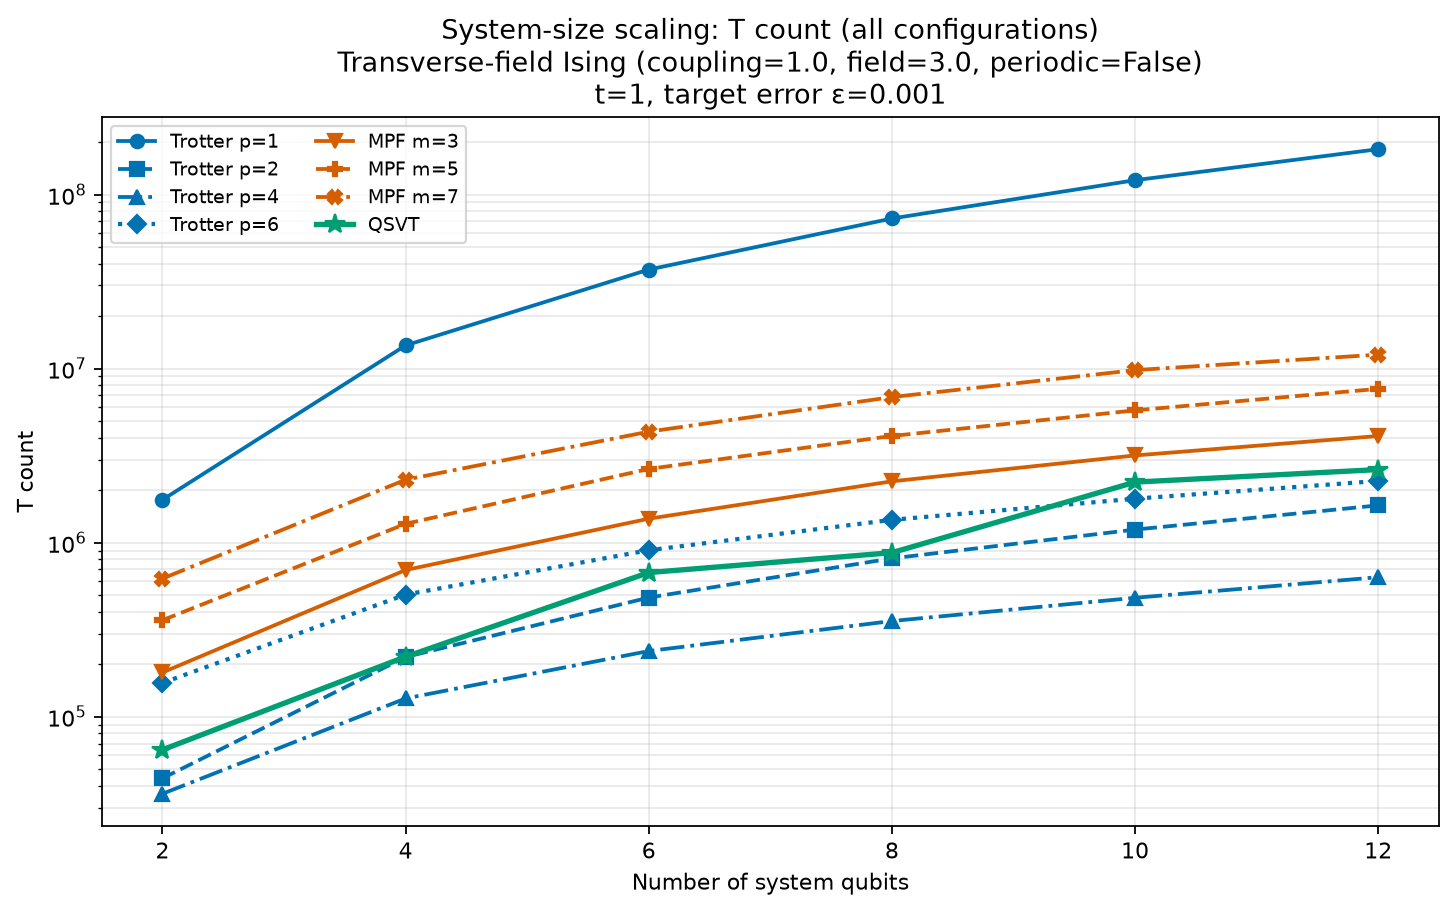

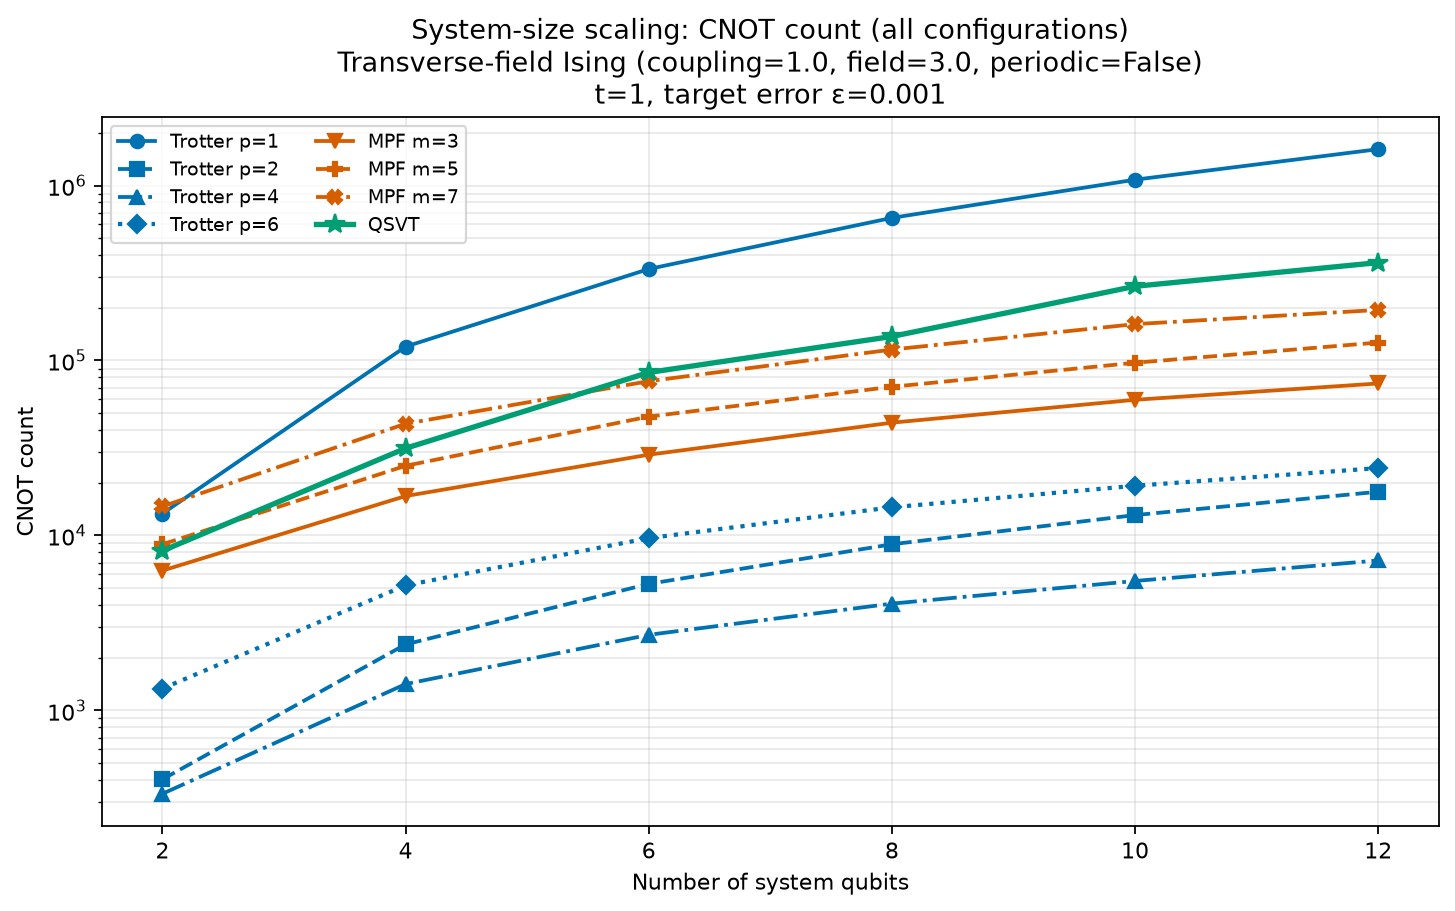

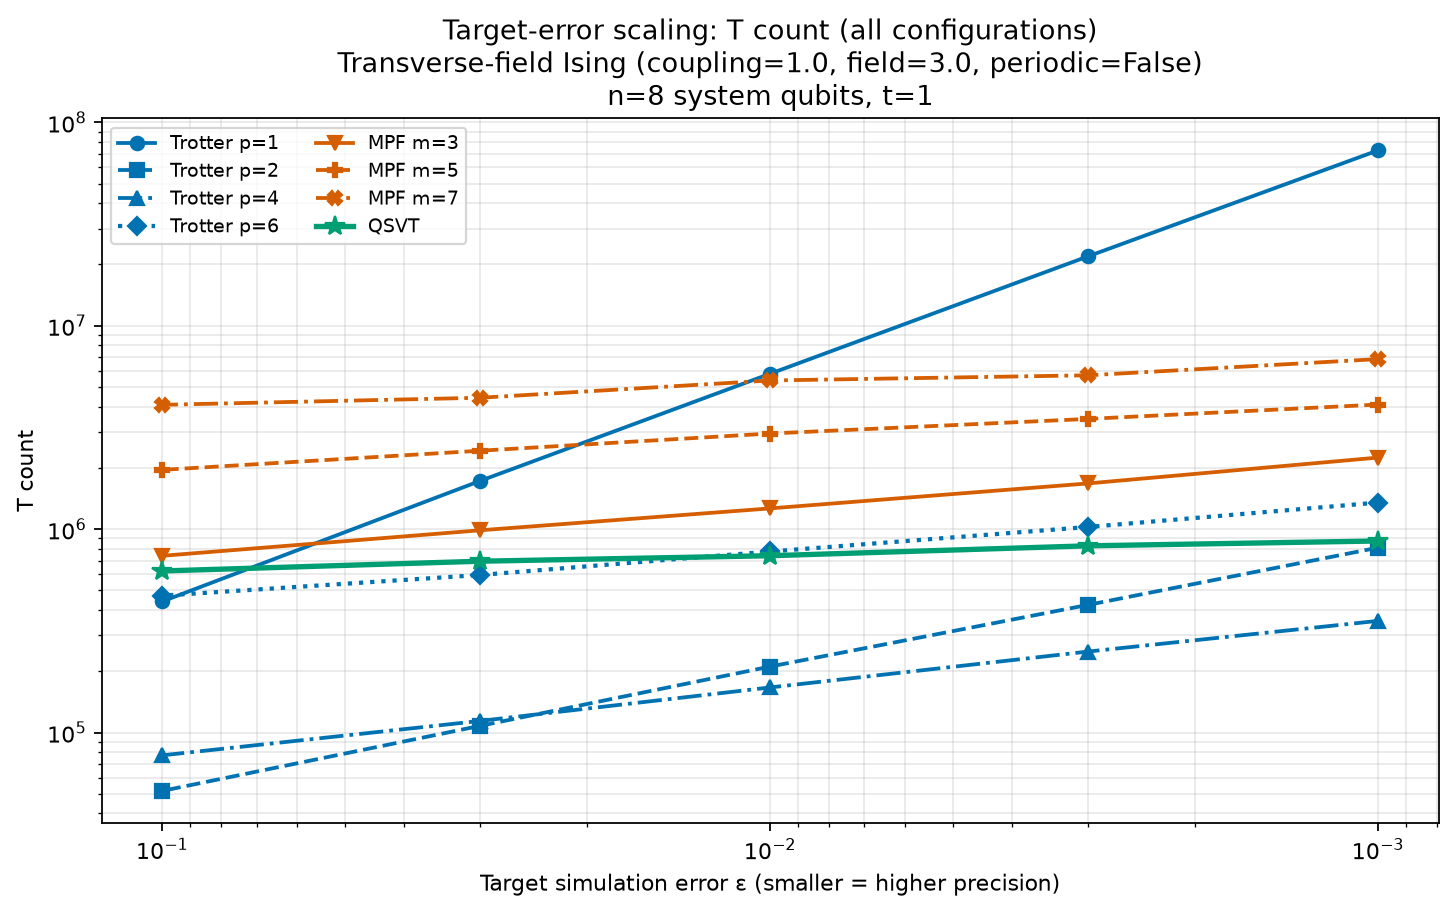

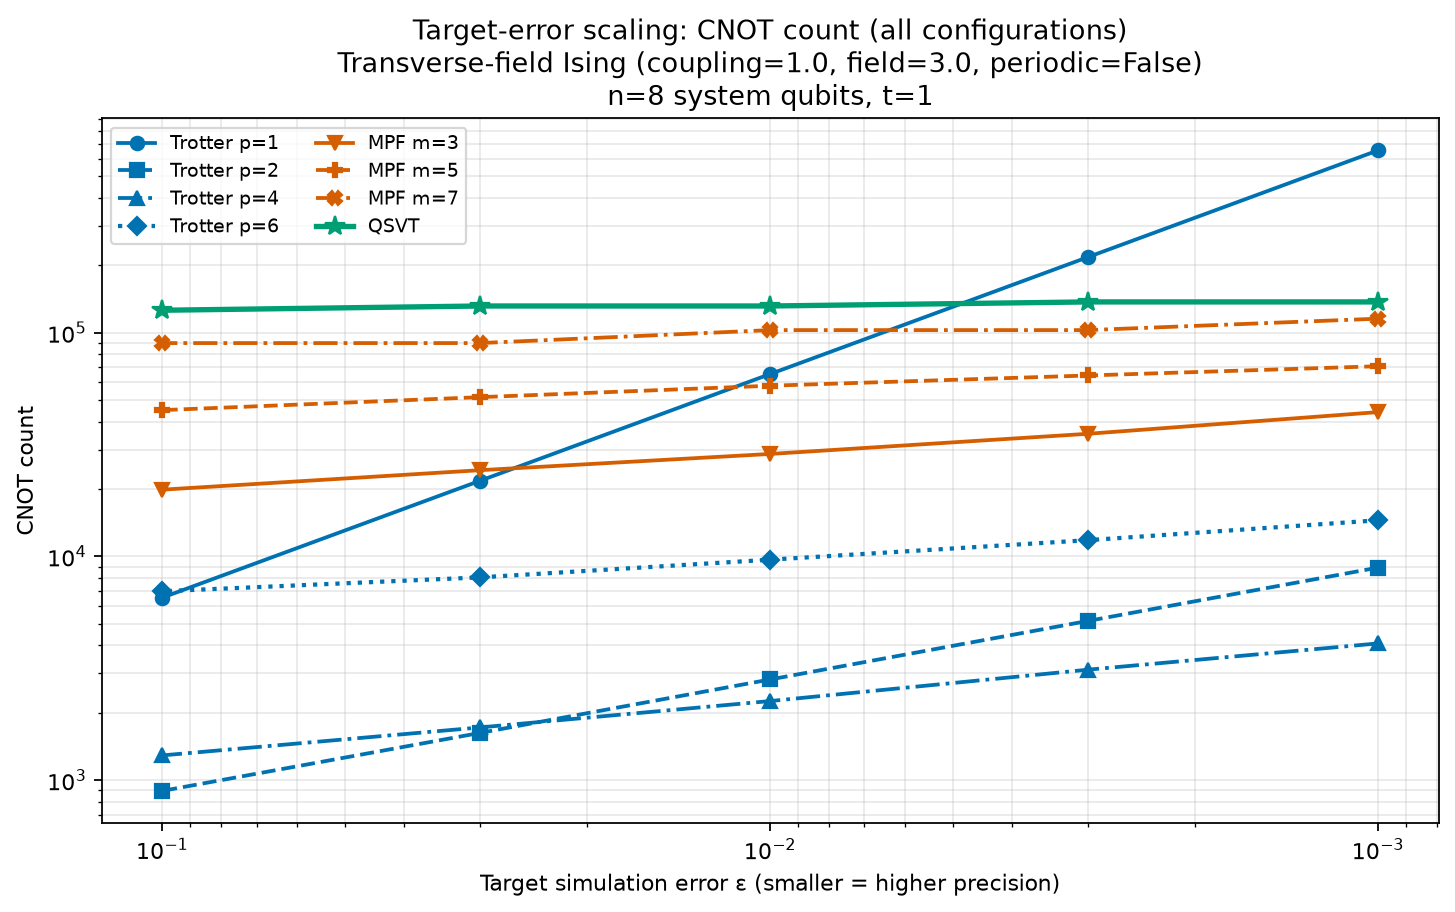

In [6]:
from io import BytesIO
from IPython.display import Image, display

figures = (
    create_benchmark_figure(system_size_resources, "t_count"),
    create_benchmark_figure(system_size_resources, "cnot_count"),
    create_benchmark_figure(target_error_resources, "t_count"),
    create_benchmark_figure(target_error_resources, "cnot_count"),
)
for figure in figures:
    image_buffer = BytesIO()
    figure.savefig(image_buffer, format="png", dpi=160, bbox_inches="tight")
    display(Image(data=image_buffer.getvalue()))

## 5. 小規模で解析モデルを transpile 値に校正

実回路の多重制御分解は急速に大きくなります。まず緩い誤差・2 qubit で試し、その後に範囲を広げてください。

In [7]:
small_config = BenchmarkConfig(time=0.05, target_error=0.2, mpf_m=2)
compiled = benchmark_scaling(
    [2], transverse_field_ising, small_config, transpile_circuits=True
)
compiled[["algorithm", "num_qubits", "t_count", "cnot_count", "depth"]]

,algorithm,num_qubits,t_count,cnot_count,depth
0,trotter,2,104,4,11
1,multiproduct,4,39150,814,1839
2,qsvt,6,2768304,89668,191028


### 解釈上の注意

- QSVT の PREPARE/SELECT コストは Hamiltonian の入力モデルに強く依存します。ここでは一般の Pauli-LCU を公平に数えています。
- 8構成とも決定的動作あたりの比較です。MPF と QSVT の解析値は segment / 回路ごとの 3-step robust OAA を含み、`nominal_success_probability` は 1 です。
- Trotter次数1, 2はChilds交換子上界、次数4, 6はgroup数がwork cap内ならSchubert--Mendl交換子上界を使います。fallbackはCSVの`bound_method`と`bound_rigorous`で明示されます。QSVTの次数は厳密なJacobi–Anger打ち切りです。MPFのsegment数だけは`alpha_eff = min(alpha, W2^(1/3))`による交換子校正proxyであり、小規模では`compare_with_exact`で校正してください。
- 解析モデルの controlled QSVT は、`V`/`V^dagger` が block-encoding query を共有し projector 位相のみ選択する効率的コンパイルを仮定します。上の `transpile_circuits=True` の校正値は Qiskit の汎用 `.control()` 分解を数えるため、解析値よりかなり大きくなります。
- family summaryは各x値で保存済みrowをpost-processした結果で、評価対象外のTrotter次数やMPF term数を最適化したものではありません。QSVTの優位は$\alpha t$が大きく、かつ誤差要求が厳しい領域（$\log(1/\varepsilon)$ scaling）で現れます。